In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix
)

data_path = Path("../data/processed/order_level_features.csv")

df = pd.read_csv(
    data_path,
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_estimated_delivery_date"
    ]
)

df.shape

(96456, 37)

In [2]:
train_df = df[
    df["order_purchase_timestamp"] < "2018-01-01"
].copy()

validation_df = df[
    (df["order_purchase_timestamp"] >= "2018-01-01")
    & (df["order_purchase_timestamp"] < "2018-07-01")
].copy()

test_df = df[
    df["order_purchase_timestamp"] >= "2018-07-01"
].copy()

In [3]:
numeric_features = [
    "number_of_items",
    "number_of_unique_products",
    "number_of_unique_sellers",
    "total_product_price",
    "total_freight_value",
    "average_product_weight_g",
    "average_product_length_cm",
    "average_product_height_cm",
    "average_product_width_cm",
    "number_of_product_categories",
    "total_payment_installments",
    "total_payment_value",
    "number_of_payment_records",
    "purchase_month",
    "purchase_day_of_week",
    "purchase_hour",
    "approval_delay_hours",
    "estimated_delivery_days",
    "estimated_delivery_days_invalid",
    "total_order_cost",
    "freight_ratio",
    "average_item_price",
    "average_product_volume_cm3",
    "product_dimensions_missing",
    "payment_information_missing"
]

categorical_features = [
    "customer_state",
    "primary_payment_type"
]

feature_columns = numeric_features + categorical_features

target_column = "late_delivery"

In [4]:
X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_validation = validation_df[feature_columns].copy()
y_validation = validation_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

In [5]:
def evaluate_model(model, X, y, model_name):
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]

    return pd.DataFrame([{
        "model": model_name,
        "accuracy": round(accuracy_score(y, predictions), 4),
        "precision": round(
            precision_score(y, predictions, zero_division=0),
            4
        ),
        "recall": round(
            recall_score(y, predictions, zero_division=0),
            4
        ),
        "f1_score": round(
            f1_score(y, predictions, zero_division=0),
            4
        ),
        "roc_auc": round(roc_auc_score(y, probabilities), 4),
        "pr_auc": round(
            average_precision_score(y, probabilities),
            4
        )
    }])

In [6]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Unknown"
            )
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, numeric_features),
        ("categorical", categorical_preprocessor, categorical_features)
    ]
)

In [7]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['number_of_items','number_of_unique_products','number_of_unique_sellers', ...,'payment_information_missing','customer_state','primary_payment_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedco

In [8]:
selected_threshold = 0.50

In [9]:
validation_scores = logistic_pipeline.predict_proba(
    X_validation
)[:, 1]

validation_analysis = validation_df[
    [
        "order_id",
        "order_purchase_timestamp",
        "customer_state",
        "primary_payment_type",
        "number_of_items",
        "number_of_unique_sellers",
        "total_product_price",
        "total_freight_value",
        "average_product_weight_g",
        "approval_delay_hours",
        "estimated_delivery_days",
        "late_delivery"
    ]
].copy()

validation_analysis["late_delivery_risk_score"] = (
    validation_scores
)

validation_analysis["predicted_late_delivery"] = (
    validation_analysis["late_delivery_risk_score"]
    >= selected_threshold
).astype(int)

In [10]:
validation_analysis

,order_id,order_purchase_timestamp,customer_state,primary_payment_type,number_of_items,number_of_unique_sellers,total_product_price,total_freight_value,average_product_weight_g,approval_delay_hours,estimated_delivery_days,late_delivery,late_delivery_risk_score,predicted_late_delivery
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,SP,credit_card,1,1,19.90,8.72,250.0,1.030556,12.069109,0,0.340390,0
11,82566a660a982b15fb86e904c8d32918,2018-06-07 10:06:19,MG,boleto,1,1,31.90,18.23,450.0,41.114722,38.865833,0,0.147482,0
13,432aaf21d85167c2c86ec9448c4e42cc,2018-03-01 14:14:28,SP,credit_card,1,1,38.25,16.11,583.0,0.938611,19.367512,0,0.236668,0
14,dcb36b511fcac050b97cd5c05de84dc3,2018-06-07 19:03:12,GO,credit_card,1,1,132.40,14.05,150.0,124.463889,21.020116,0,0.703377,1
15,403b97836b0c04a622354cf531062e5f,2018-01-02 19:00:43,RJ,credit_card,1,1,1299.00,77.45,20850.0,0.139167,34.202037,0,0.608007,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96443,c22a47117b6a87c967b0c278488110c1,2018-06-22 20:53:29,SP,credit_card,1,1,149.90,16.06,1956.0,0.404444,30.112674,0,0.247974,0
96445,c81f74e50f0496fa39716cc77cacd460,2018-03-04 22:48:38,MG,credit_card,1,1,55.00,15.83,250.0,0.345556,21.035162,0,0.198283,0
96452,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,SP,credit_card,1,1,174.90,20.10,4950.0,0.194167,23.450961,0,0.223983,0
96454,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,RJ,credit_card,2,1,359.98,81.18,6550.0,0.131667,37.099757,0,0.269843,0


In [11]:
validation_analysis["prediction_outcome"] = np.select(
    [
        (
            (validation_analysis["late_delivery"] == 1)
            & (validation_analysis["predicted_late_delivery"] == 1)
        ),
        (
            (validation_analysis["late_delivery"] == 0)
            & (validation_analysis["predicted_late_delivery"] == 1)
        ),
        (
            (validation_analysis["late_delivery"] == 1)
            & (validation_analysis["predicted_late_delivery"] == 0)
        )
    ],
    [
        "True Positive",
        "False Positive",
        "False Negative"
    ],
    default="True Negative"
)

validation_analysis["prediction_outcome"].value_counts()

prediction_outcome
True Negative     32722
False Positive     3540
False Negative     3023
True Positive       985
Name: count, dtype: int64

In [12]:
false_positives = validation_analysis[
    validation_analysis["prediction_outcome"] == "False Positive"
].copy()

false_negatives = validation_analysis[
    validation_analysis["prediction_outcome"] == "False Negative"
].copy()

In [13]:
false_positives.sort_values(
    "late_delivery_risk_score",
    ascending=False
).head(15)

,order_id,order_purchase_timestamp,customer_state,primary_payment_type,number_of_items,number_of_unique_sellers,total_product_price,total_freight_value,average_product_weight_g,approval_delay_hours,estimated_delivery_days,late_delivery,late_delivery_risk_score,predicted_late_delivery,prediction_outcome
10105,7fc19fa60f9bb0d99b980a47eee3ec28,2018-04-20 20:42:38,AL,credit_card,1,1,69.00,50.98,1400.0,94.724722,21.190197,0,0.921197,1,False Positive
39136,8dbc85d1447242f3b127dda390d56e19,2018-06-22 12:23:19,PB,credit_card,1,1,4590.00,91.78,2900.0,0.221389,24.474583,0,0.916808,1,False Positive
65884,4433add7ec1811cbdb34a289d636f1f3,2018-06-12 21:35:49,AL,credit_card,1,1,209.99,35.68,4650.0,65.462222,26.372535,0,0.908472,1,False Positive
86228,46df573bb73f96f2ac4ed61858107f75,2018-03-30 18:55:43,AL,credit_card,1,1,1595.00,63.81,5600.0,0.241667,25.201238,0,0.900218,1,False Positive
33933,1efe916e0147732877ae7c2ae6a245ba,2018-04-24 14:39:42,AL,credit_card,1,1,750.00,106.89,8850.0,3.609444,23.238704,0,0.885394,1,False Positive
1862,3f6a06dd65ecc8c3c8bf73dd9f5ade29,2018-06-29 11:19:19,MA,boleto,1,1,104.99,57.51,1450.0,148.747500,21.330440,0,0.884449,1,False Positive
72694,559e3bc7d9dd587ccb23c90505340ee1,2018-04-19 06:56:40,AL,boleto,2,1,107.80,0.00,1550.0,131.138889,28.246528,0,0.883870,1,False Positive
27950,201c5ac9debe4c98c375ceaa9172cc87,2018-06-22 13:20:17,AL,credit_card,2,1,70.00,49.20,1400.0,69.561111,29.545868,0,0.878480,1,False Positive
26099,67c8c2016ddabf0059783eb44e921f99,2018-04-30 20:20:45,AL,boleto,1,1,44.06,24.48,1100.0,55.241111,20.850544,0,0.878227,1,False Positive
21904,5000db43709b8a1e13f508043ff281c9,2018-04-17 17:08:56,RJ,credit_card,1,1,143.80,25.82,5950.0,169.828056,16.209294,0,0.872886,1,False Positive


In [14]:
false_negatives.sort_values(
    "late_delivery_risk_score",
    ascending=True
).head(15)

,order_id,order_purchase_timestamp,customer_state,primary_payment_type,number_of_items,number_of_unique_sellers,total_product_price,total_freight_value,average_product_weight_g,approval_delay_hours,estimated_delivery_days,late_delivery,late_delivery_risk_score,predicted_late_delivery,prediction_outcome
46614,cf788ee4258fde5130bb5651bda63918,2018-03-02 16:18:31,MG,credit_card,2,2,179.80,44.13,6825.0,0.224722,20.311111,1,0.080071,0,False Negative
28778,f6151443391cbb0f7fb0fcaf6d79e963,2018-01-29 11:48:36,PR,boleto,1,1,189.90,16.08,100.0,17.716389,41.769734,1,0.084421,0,False Negative
78389,f939e2a89376e44158657a15465cacce,2018-01-08 16:02:04,RJ,boleto,3,1,239.97,68.64,11880.0,15.391111,68.690602,1,0.096601,0,False Negative
81474,d23957cc89dc81d6073de66716d2cf82,2018-02-07 19:59:03,MG,credit_card,2,1,288.82,34.90,140.0,0.274444,35.155891,1,0.100240,0,False Negative
8937,5d1e025052895991d3f50688be8f626e,2018-01-28 11:07:48,RO,credit_card,1,1,53.90,21.18,500.0,0.206389,38.527650,1,0.104936,0,False Negative
95639,1b2fd2d45589bc249ee9ae90fdb05a6b,2018-02-25 09:47:41,MG,credit_card,1,1,148.00,17.00,125.0,0.348333,31.577373,1,0.105595,0,False Negative
9038,6cc24bf6c628c261d2f9f0f7eef52a93,2018-02-22 21:58:26,MG,credit_card,2,1,142.80,17.00,193.5,0.202222,32.075995,1,0.108983,0,False Negative
87065,e3c2135c38233042e0bfa35a97882582,2018-01-17 22:10:43,MG,credit_card,1,1,10.90,16.79,900.0,0.147778,32.069734,1,0.109677,0,False Negative
3647,893898b048df9dfeafedf2c86eb5037c,2018-02-08 09:24:47,MG,credit_card,1,1,110.99,23.10,700.0,0.178611,32.600347,1,0.114378,0,False Negative
23061,410ba50fe8c000ab2342ac8e4282b2f3,2018-01-23 12:53:17,MG,credit_card,1,1,219.00,17.97,600.0,0.316944,30.449792,1,0.114935,0,False Negative


In [15]:
late_order_comparison = (
    validation_analysis[
        validation_analysis["late_delivery"] == 1
    ]
    .groupby("prediction_outcome")
    .agg(
        orders=("order_id", "size"),
        average_risk_score=(
            "late_delivery_risk_score",
            "mean"
        ),
        average_freight_value=(
            "total_freight_value",
            "mean"
        ),
        average_product_weight_g=(
            "average_product_weight_g",
            "mean"
        ),
        average_approval_delay_hours=(
            "approval_delay_hours",
            "mean"
        ),
        average_estimated_delivery_days=(
            "estimated_delivery_days",
            "mean"
        ),
        average_number_of_sellers=(
            "number_of_unique_sellers",
            "mean"
        )
    )
    .round(2)
)

late_order_comparison

,orders,average_risk_score,average_freight_value,average_product_weight_g,average_approval_delay_hours,average_estimated_delivery_days,average_number_of_sellers
prediction_outcome,,,,,,,
False Negative,3023,0.34,22.46,1878.11,8.81,22.79,1.0
True Positive,985,0.60,35.23,3426.10,19.18,22.37,1.0


In [16]:
feature_names = (
    logistic_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_pipeline
    .named_steps["model"]
    .coef_[0]
)

coefficient_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coefficient_importance["absolute_coefficient"] = (
    coefficient_importance["coefficient"].abs()
)

coefficient_importance["direction"] = np.where(
    coefficient_importance["coefficient"] > 0,
    "Higher late-delivery risk",
    "Lower late-delivery risk"
)

In [17]:
top_features = coefficient_importance.sort_values(
    "absolute_coefficient",
    ascending=False
).head(15)

top_features

,feature,coefficient,absolute_coefficient,direction
26,categorical__customer_state_AL,1.584738,1.584738,Higher late-delivery risk
46,categorical__customer_state_RR,1.518496,1.518496,Higher late-delivery risk
35,categorical__customer_state_MG,-1.228066,1.228066,Lower late-delivery risk
28,categorical__customer_state_AP,1.128259,1.128259,Higher late-delivery risk
50,categorical__customer_state_SP,-1.106386,1.106386,Lower late-delivery risk
42,categorical__customer_state_PR,-1.072378,1.072378,Lower late-delivery risk
45,categorical__customer_state_RO,-0.838304,0.838304,Lower late-delivery risk
34,categorical__customer_state_MA,0.794399,0.794399,Higher late-delivery risk
36,categorical__customer_state_MS,-0.783690,0.783690,Lower late-delivery risk
39,categorical__customer_state_PB,0.722421,0.722421,Higher late-delivery risk


In [18]:
coefficient_importance.sort_values(
    "coefficient",
    ascending=False
).head(10)

,feature,coefficient,absolute_coefficient,direction
26,categorical__customer_state_AL,1.584738,1.584738,Higher late-delivery risk
46,categorical__customer_state_RR,1.518496,1.518496,Higher late-delivery risk
28,categorical__customer_state_AP,1.128259,1.128259,Higher late-delivery risk
34,categorical__customer_state_MA,0.794399,0.794399,Higher late-delivery risk
39,categorical__customer_state_PB,0.722421,0.722421,Higher late-delivery risk
49,categorical__customer_state_SE,0.709815,0.709815,Higher late-delivery risk
44,categorical__customer_state_RN,0.466109,0.466109,Higher late-delivery risk
41,categorical__customer_state_PI,0.441562,0.441562,Higher late-delivery risk
29,categorical__customer_state_BA,0.344944,0.344944,Higher late-delivery risk
13,numeric__purchase_month,0.338634,0.338634,Higher late-delivery risk


In [19]:
coefficient_importance.sort_values(
    "coefficient",
    ascending=True
).head(10)

,feature,coefficient,absolute_coefficient,direction
35,categorical__customer_state_MG,-1.228066,1.228066,Lower late-delivery risk
50,categorical__customer_state_SP,-1.106386,1.106386,Lower late-delivery risk
42,categorical__customer_state_PR,-1.072378,1.072378,Lower late-delivery risk
45,categorical__customer_state_RO,-0.838304,0.838304,Lower late-delivery risk
36,categorical__customer_state_MS,-0.783690,0.783690,Lower late-delivery risk
31,categorical__customer_state_DF,-0.715951,0.715951,Lower late-delivery risk
51,categorical__customer_state_TO,-0.558752,0.558752,Lower late-delivery risk
17,numeric__estimated_delivery_days,-0.399547,0.399547,Lower late-delivery risk
47,categorical__customer_state_RS,-0.389700,0.389700,Lower late-delivery risk
33,categorical__customer_state_GO,-0.371821,0.371821,Lower late-delivery risk


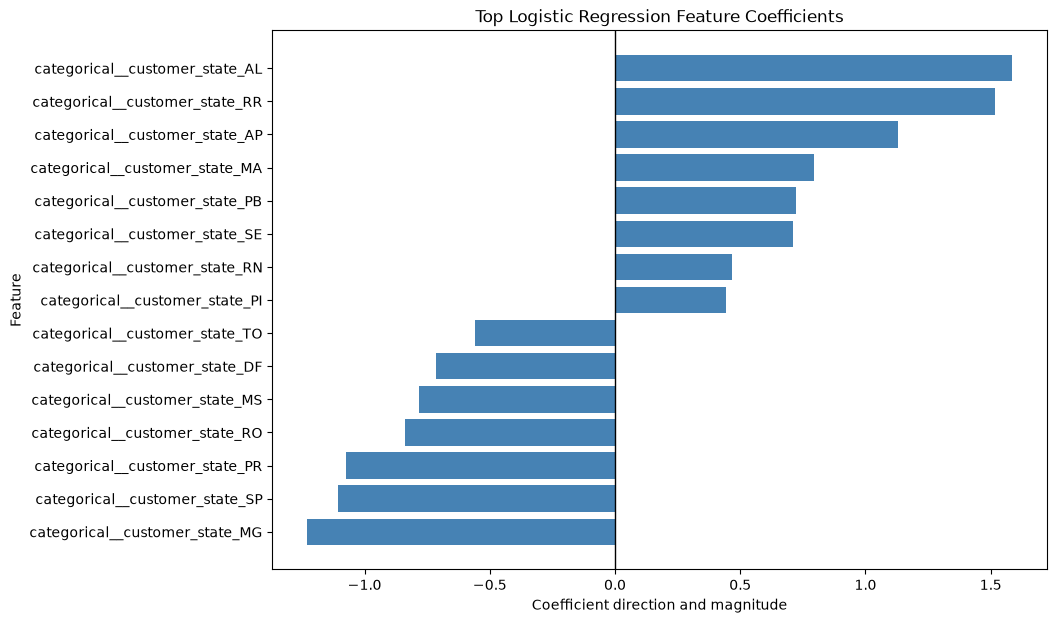

In [20]:
plot_features = top_features.sort_values(
    "coefficient",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_features["feature"],
    plot_features["coefficient"],
    color="steelblue"
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Top Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient direction and magnitude")
plt.ylabel("Feature")
plt.show()

In [21]:
validation_analysis["true_positive"] = (
    (
        validation_analysis["late_delivery"] == 1
    )
    & (
        validation_analysis["predicted_late_delivery"] == 1
    )
).astype(int)

validation_analysis["false_negative"] = (
    (
        validation_analysis["late_delivery"] == 1
    )
    & (
        validation_analysis["predicted_late_delivery"] == 0
    )
).astype(int)

validation_analysis["false_positive"] = (
    (
        validation_analysis["late_delivery"] == 0
    )
    & (
        validation_analysis["predicted_late_delivery"] == 1
    )
).astype(int)

In [22]:
state_performance = (
    validation_analysis
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "size"),
        actual_late_orders=("late_delivery", "sum"),
        predicted_late_orders=(
            "predicted_late_delivery",
            "sum"
        ),
        true_positives=("true_positive", "sum"),
        false_positives=("false_positive", "sum"),
        false_negatives=("false_negative", "sum")
    )
    .reset_index()
)

state_performance["recall"] = (
    state_performance["true_positives"]
    / state_performance["actual_late_orders"]
)

state_performance["precision"] = (
    state_performance["true_positives"]
    / state_performance["predicted_late_orders"]
)

state_performance["actual_late_rate"] = (
    state_performance["actual_late_orders"]
    / state_performance["total_orders"]
)

state_performance = state_performance[
    state_performance["actual_late_orders"] >= 30
].copy()

state_performance[
    [
        "customer_state",
        "total_orders",
        "actual_late_orders",
        "recall",
        "precision",
        "actual_late_rate"
    ]
].sort_values("recall")

,customer_state,total_orders,actual_late_orders,recall,precision,actual_late_rate
10,MG,4735,425,0.011765,0.277778,0.089757
17,PR,2070,139,0.014388,0.083333,0.067150
25,SP,17453,953,0.034627,0.107143,0.054604
6,DF,885,85,0.035294,0.115385,0.096045
22,RS,2136,199,0.045226,0.068182,0.093165
12,MT,390,31,0.064516,0.052632,0.079487
11,MS,327,53,0.075472,0.444444,0.162080
8,GO,804,86,0.093023,0.117647,0.106965
13,PA,353,77,0.103896,0.250000,0.218130
7,ES,822,154,0.240260,0.298387,0.187348


In [23]:
payment_performance = (
    validation_analysis
    .groupby("primary_payment_type")
    .agg(
        total_orders=("order_id", "size"),
        actual_late_orders=("late_delivery", "sum"),
        predicted_late_orders=(
            "predicted_late_delivery",
            "sum"
        ),
        true_positives=("true_positive", "sum"),
        false_negatives=("false_negative", "sum")
    )
    .reset_index()
)

payment_performance["recall"] = (
    payment_performance["true_positives"]
    / payment_performance["actual_late_orders"]
)

payment_performance["actual_late_rate"] = (
    payment_performance["actual_late_orders"]
    / payment_performance["total_orders"]
)

payment_performance.sort_values("recall")

,primary_payment_type,total_orders,actual_late_orders,predicted_late_orders,true_positives,false_negatives,recall,actual_late_rate
1,credit_card,30841,3040,3214,712,2328,0.234211,0.098570
0,boleto,7679,828,1039,225,603,0.271739,0.107827
3,voucher,1179,96,167,32,64,0.333333,0.081425
2,debit_card,571,44,105,16,28,0.363636,0.077058


In [24]:
validation_analysis["risk_decile"] = pd.qcut(
    validation_analysis["late_delivery_risk_score"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

In [25]:
decile_summary = (
    validation_analysis
    .groupby("risk_decile")
    .agg(
        total_orders=("order_id", "size"),
        actual_late_rate=("late_delivery", "mean"),
        average_risk_score=(
            "late_delivery_risk_score",
            "mean"
        )
    )
    .reset_index()
)

decile_summary["actual_late_rate"] = (
    decile_summary["actual_late_rate"] * 100
).round(2)

decile_summary

,risk_decile,total_orders,actual_late_rate,average_risk_score
0,1,4027,3.23,0.135862
1,2,4027,5.04,0.194614
2,3,4027,7.47,0.230122
3,4,4027,7.10,0.262019
4,5,4027,7.75,0.293439
5,6,4027,8.07,0.325257
6,7,4027,9.73,0.362049
7,8,4027,11.75,0.407521
8,9,4027,17.11,0.470543
9,10,4027,22.27,0.597333


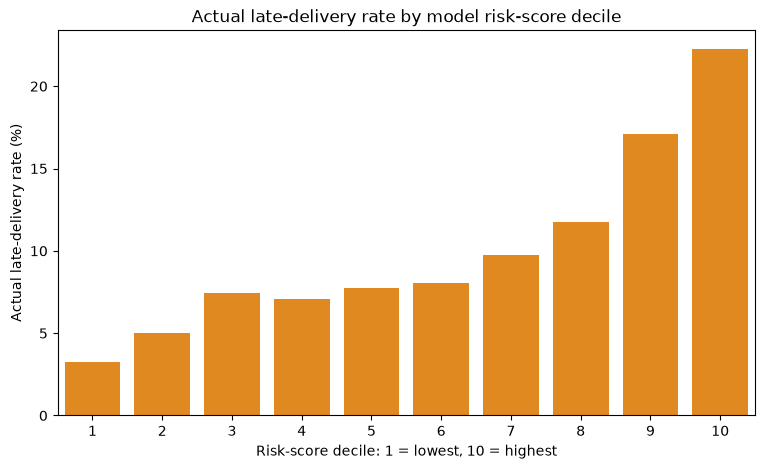

In [26]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=decile_summary,
    x="risk_decile",
    y="actual_late_rate",
    color="darkorange"
)

plt.title("Actual late-delivery rate by model risk-score decile")
plt.xlabel("Risk-score decile: 1 = lowest, 10 = highest")
plt.ylabel("Actual late-delivery rate (%)")
plt.show()

In [27]:
validation_analysis.to_csv(
    "../data/processed/validation_error_analysis.csv",
    index=False
)

coefficient_importance.to_csv(
    "../data/processed/logistic_feature_coefficients.csv",
    index=False
)